## 🔗 Topologies

**Concepts:** [Network topologies](../problem.md#network-topologies) · [Model options](../routers.md#model-options) **Advanced API:** [🔗 Topologies](lo30_topologies.ipynb)

This notebook produces each of the three electrical topologies — **branched**, **radial** and **ringed** — with every router that can generate it.

The topologies themselves are defined in [Network topologies](../problem.md#network-topologies), and the capacity accounting that makes rings different is in [Ring semantics](../problem.md#ring-semantics). Which router can enforce which topology is summarized in [What each approach can enforce](../routers.md#what-each-approach-can-enforce).

### Load Data

In [1]:
from optiwindnet.api import WindFarmNetwork, EWRouter, HGSRouter, MILPRouter, ModelOptions, load_repository
%config InlineBackend.figure_formats = ['svg']

In [2]:
locations = load_repository()

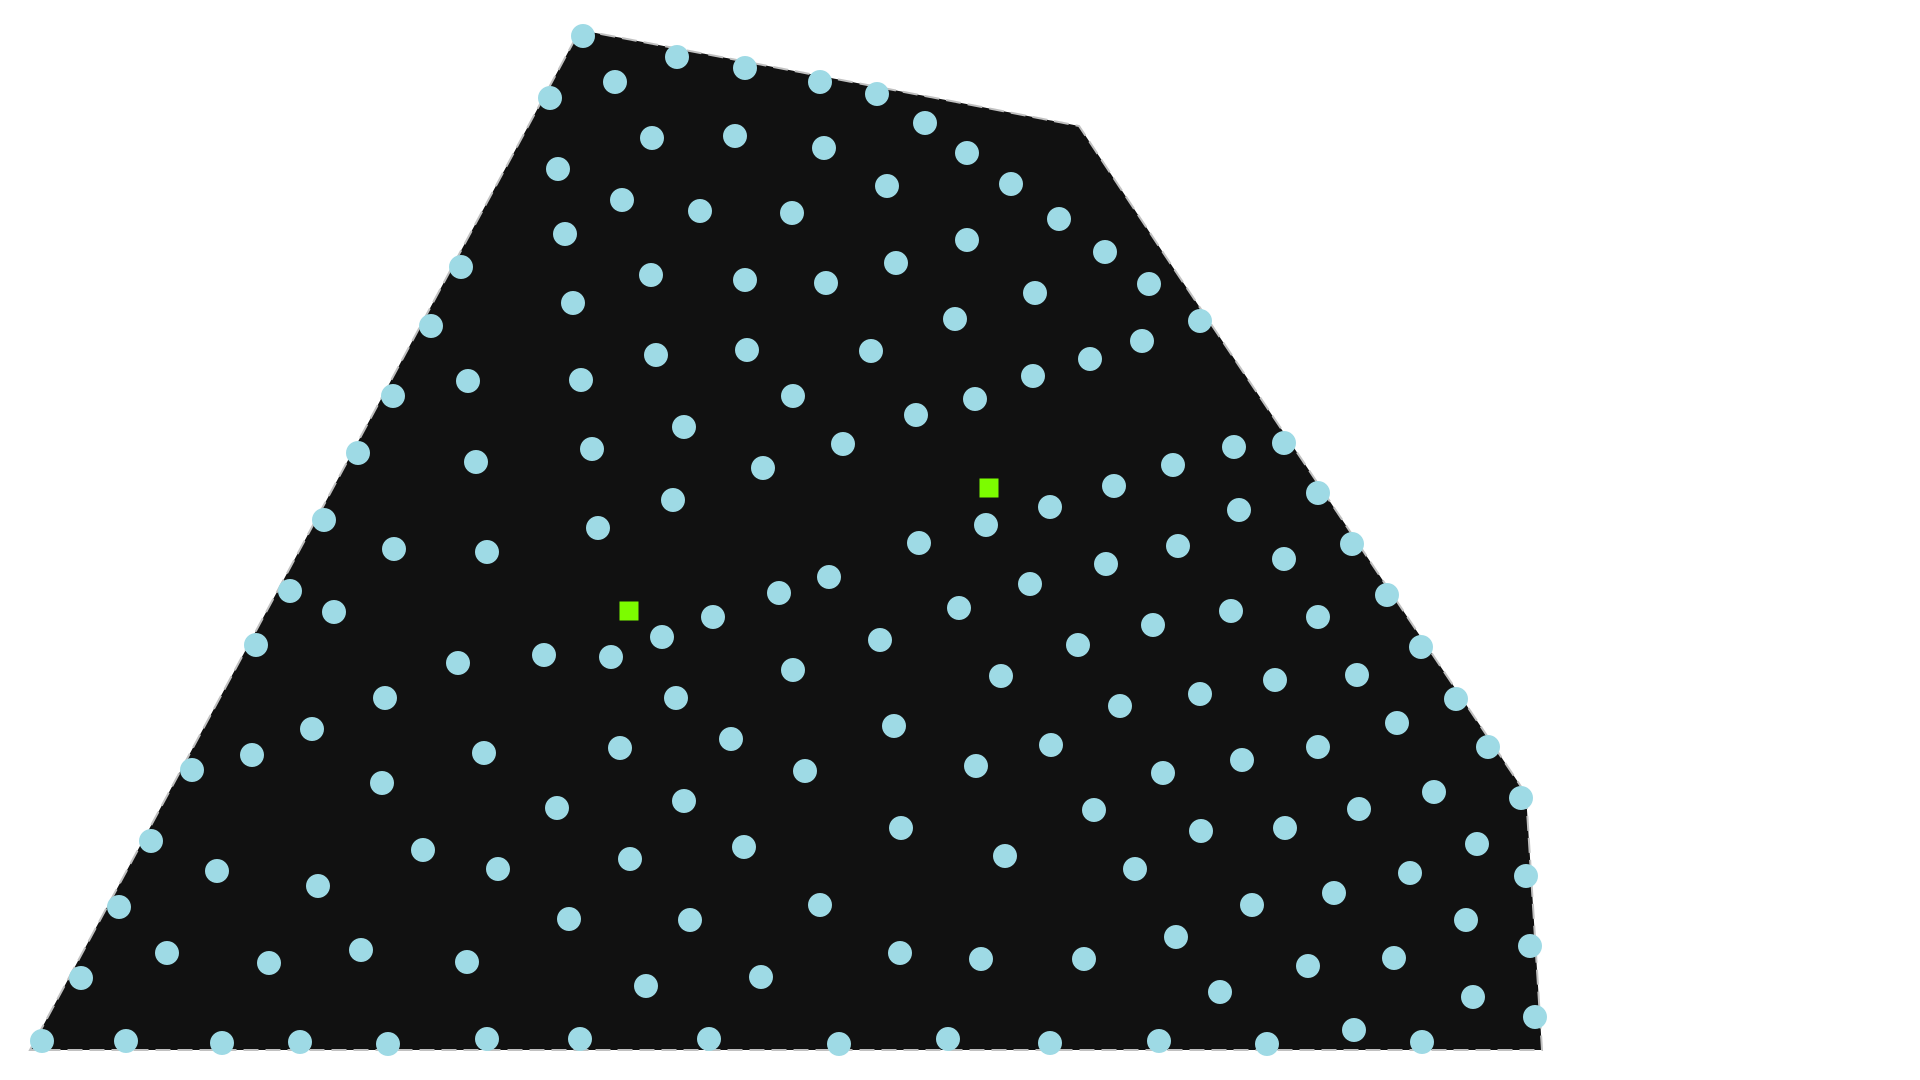

In [3]:
wfn = WindFarmNetwork(L=locations.borssele, cables=3)
wfn

### 1. Branched

The least constrained topology, and the default: a cable may branch at any turbine. [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) produces branched networks with any method other than `'radial_EW'` and `'ringed'`; [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) produces them with `topology='branched'`, also the default.

#### EWRouter

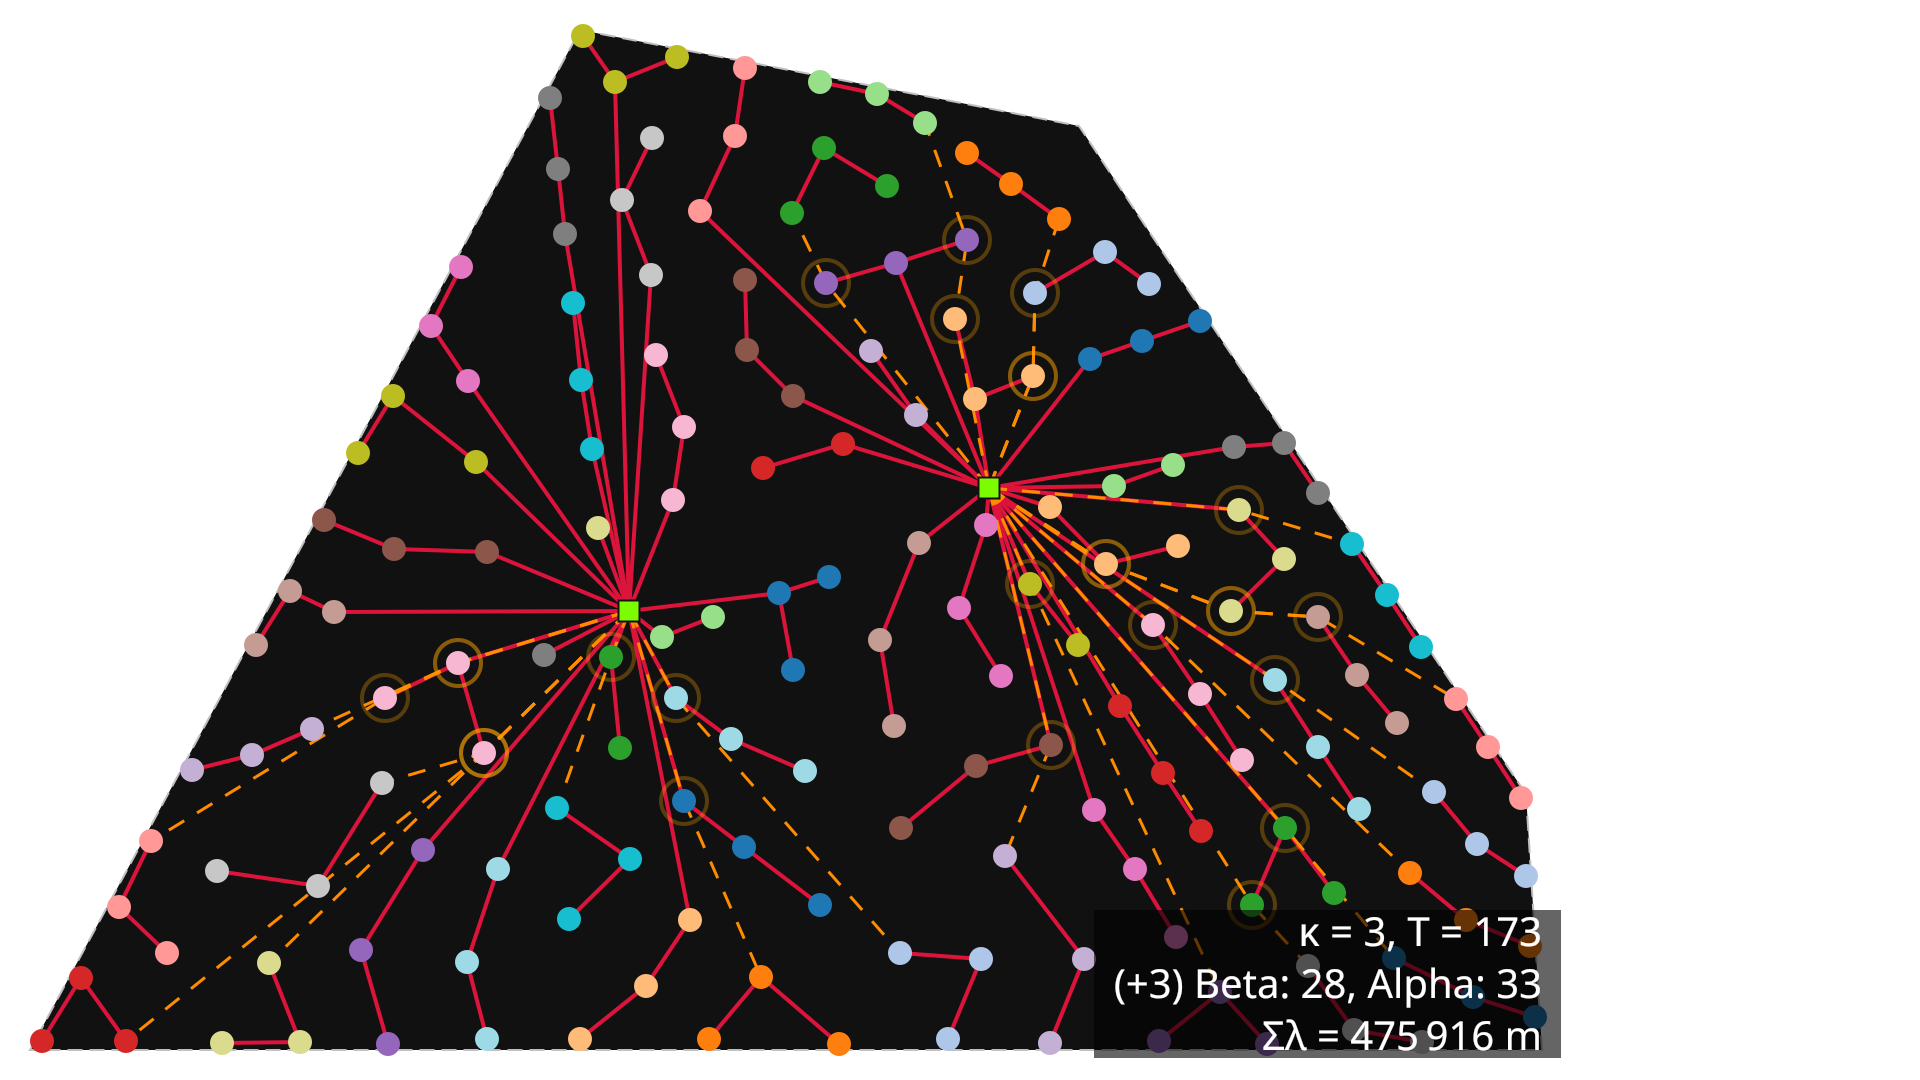

In [4]:
wfn.optimize(router=EWRouter())
wfn

#### MILPRouter

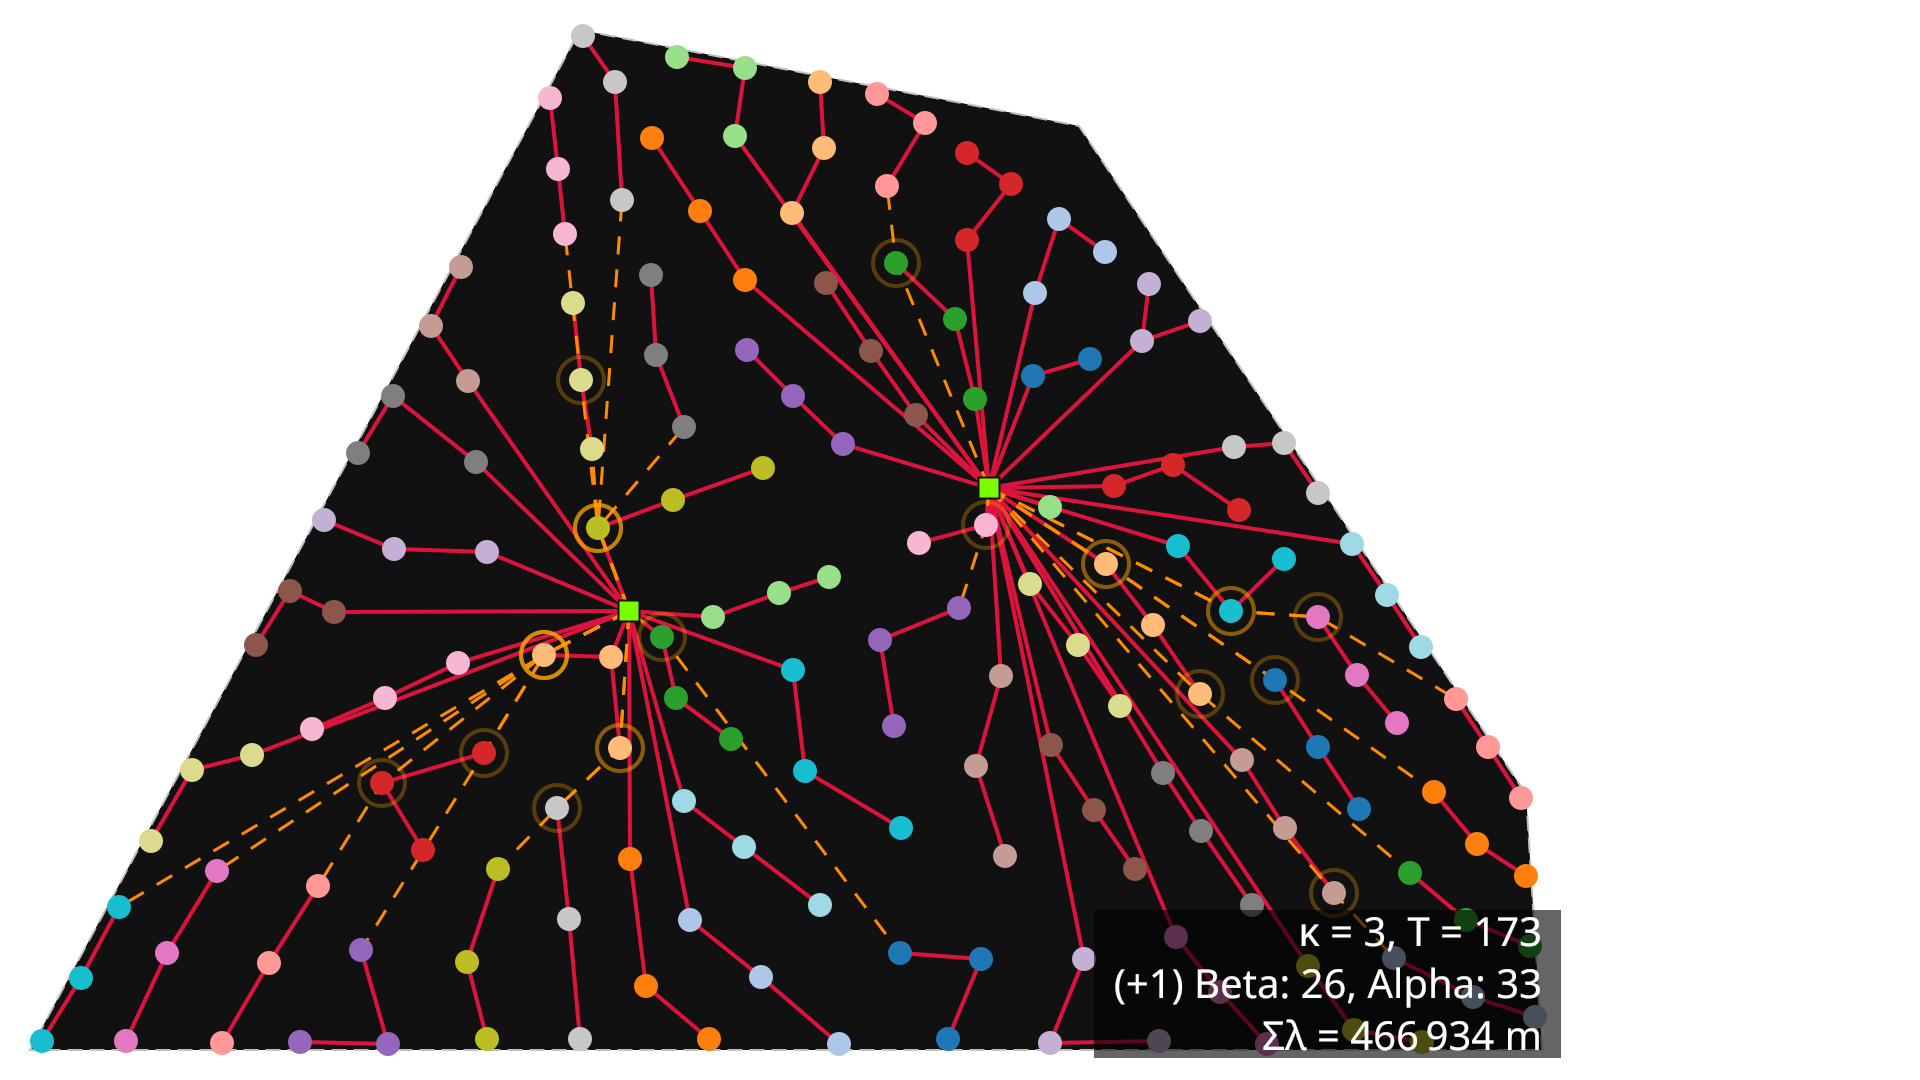

In [5]:
router_branched = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=90,
    mip_gap=0.005,
    model_options=ModelOptions(topology='branched'),
)
wfn.optimize(router=router_branched)
wfn

### 2. Radial

No branching at turbines: every subtree is a simple path from the root. [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) needs `method='radial_EW'`, [HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) produces radial networks by default, and [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) takes `topology='radial'`.

#### EWRouter

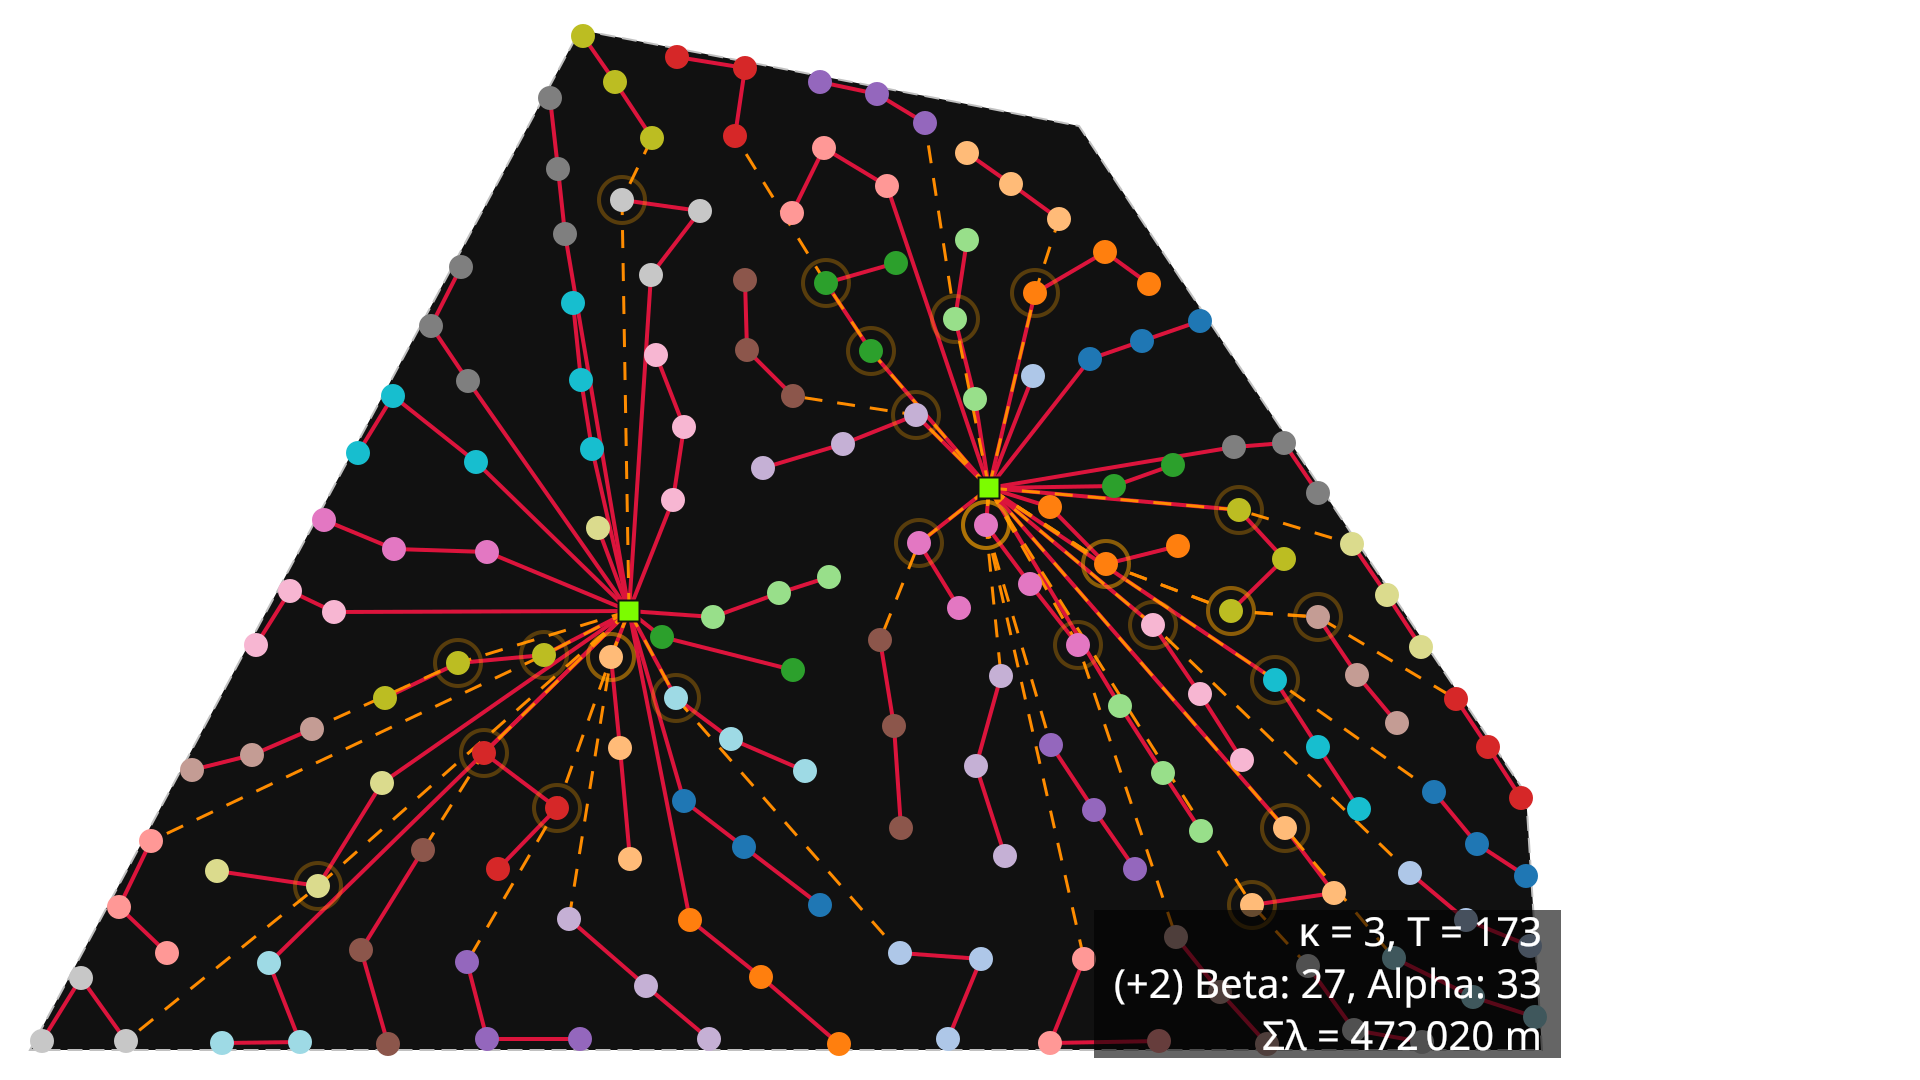

In [6]:
wfn.optimize(router=EWRouter(method='radial_EW'))
wfn

#### HGSRouter

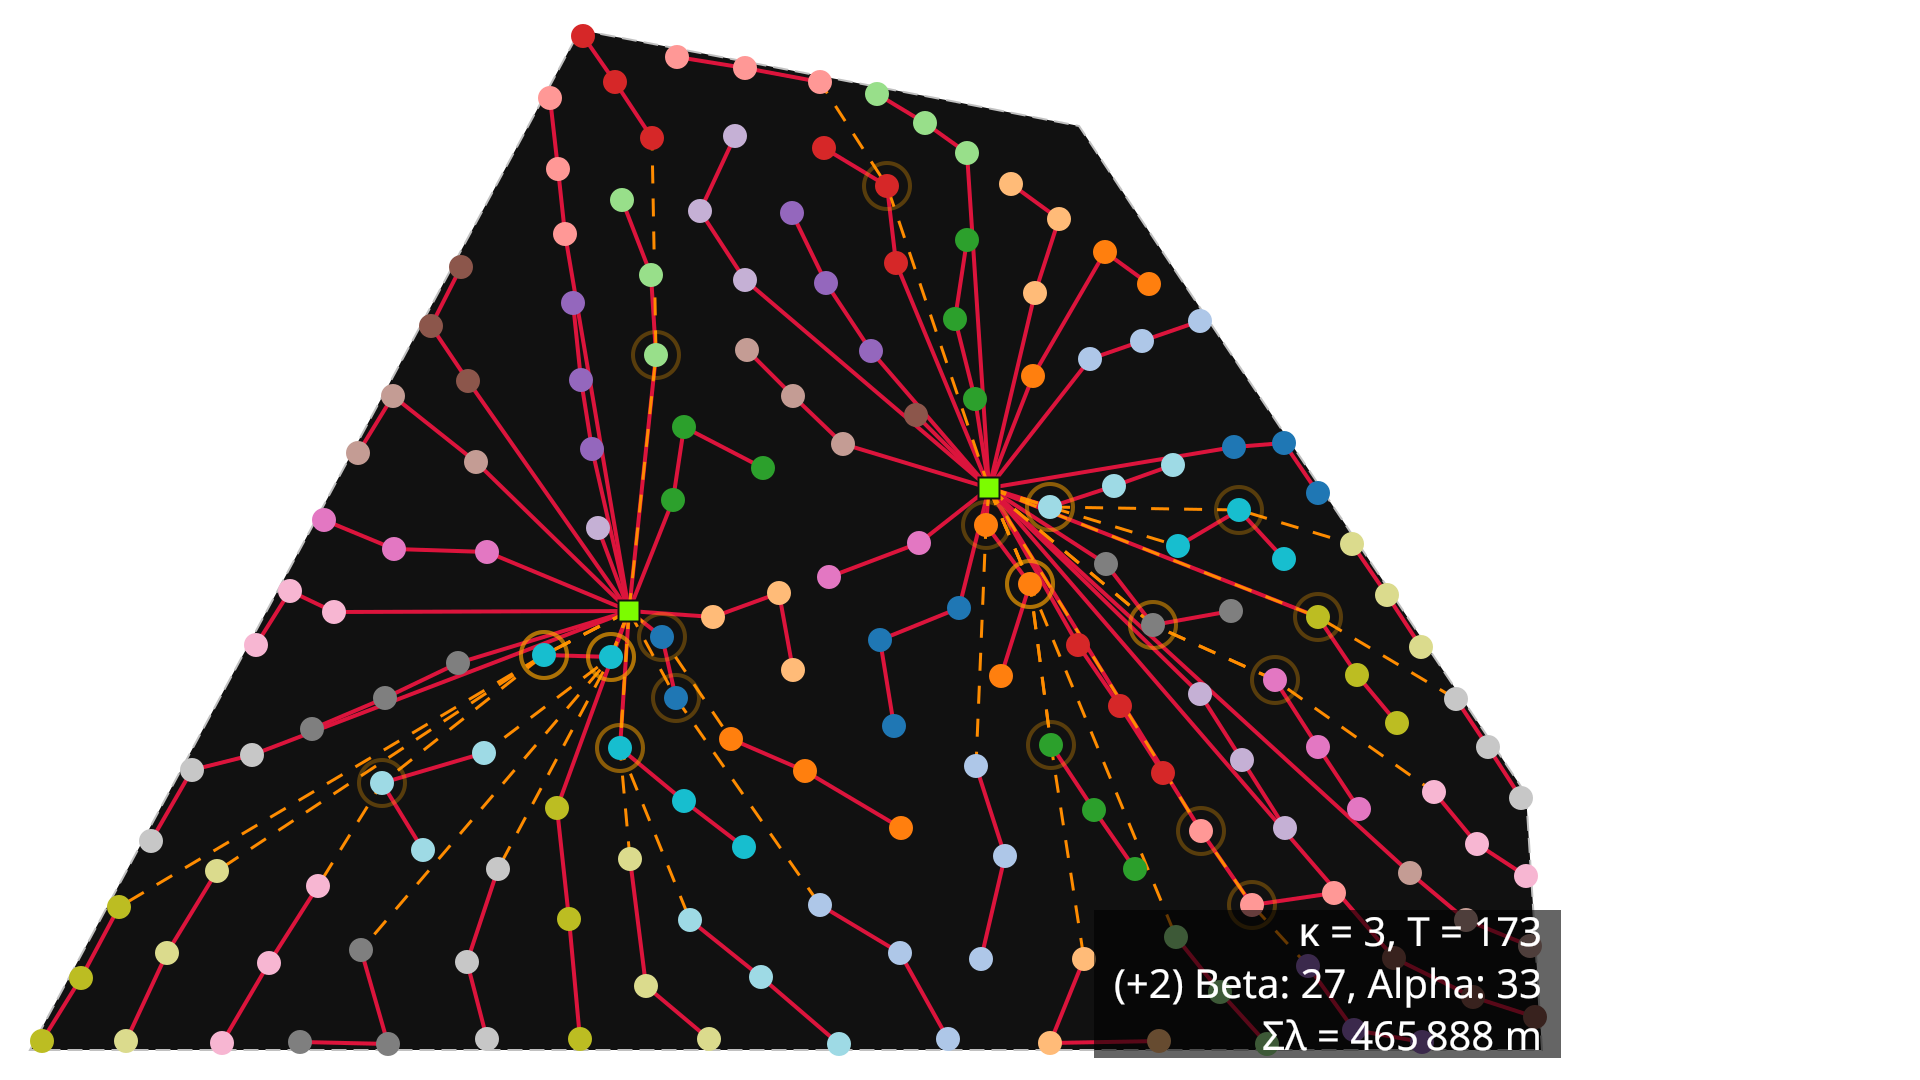

In [7]:
wfn.optimize(router=HGSRouter(time_limit=1.0))
wfn

#### MILPRouter

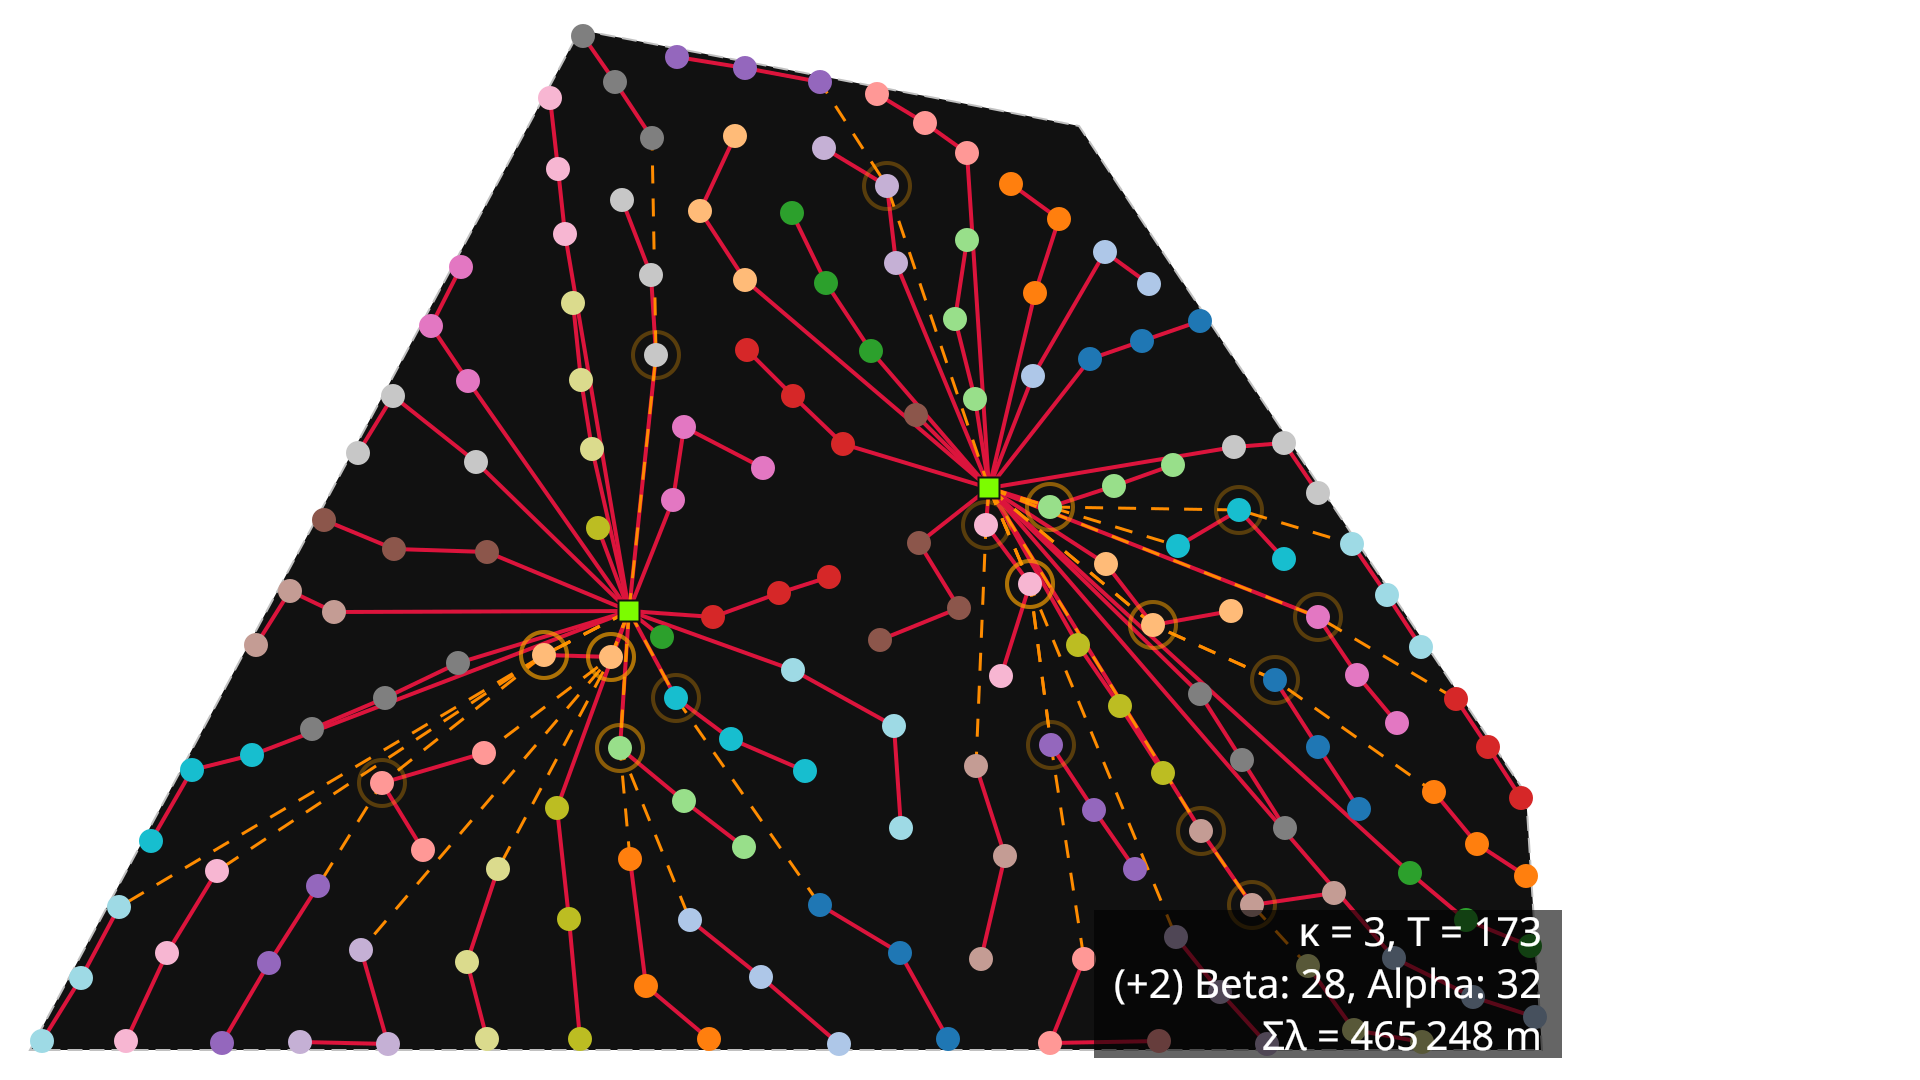

In [8]:
router_radial = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=90,
    mip_gap=0.005,
    model_options=ModelOptions(topology='radial'),
)
wfn.optimize(router=router_radial)
wfn

### 3. Ringed

Each subtree is closed into a cycle attached to the substation at both ends, so a fault anywhere along the ring still leaves every turbine on it connected. [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) provides the constructive variant `method='ringed'`, [HGSRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) takes `ringed=True` to solve a closed CVRP, and [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) takes `topology='ringed'`.

#### EWRouter

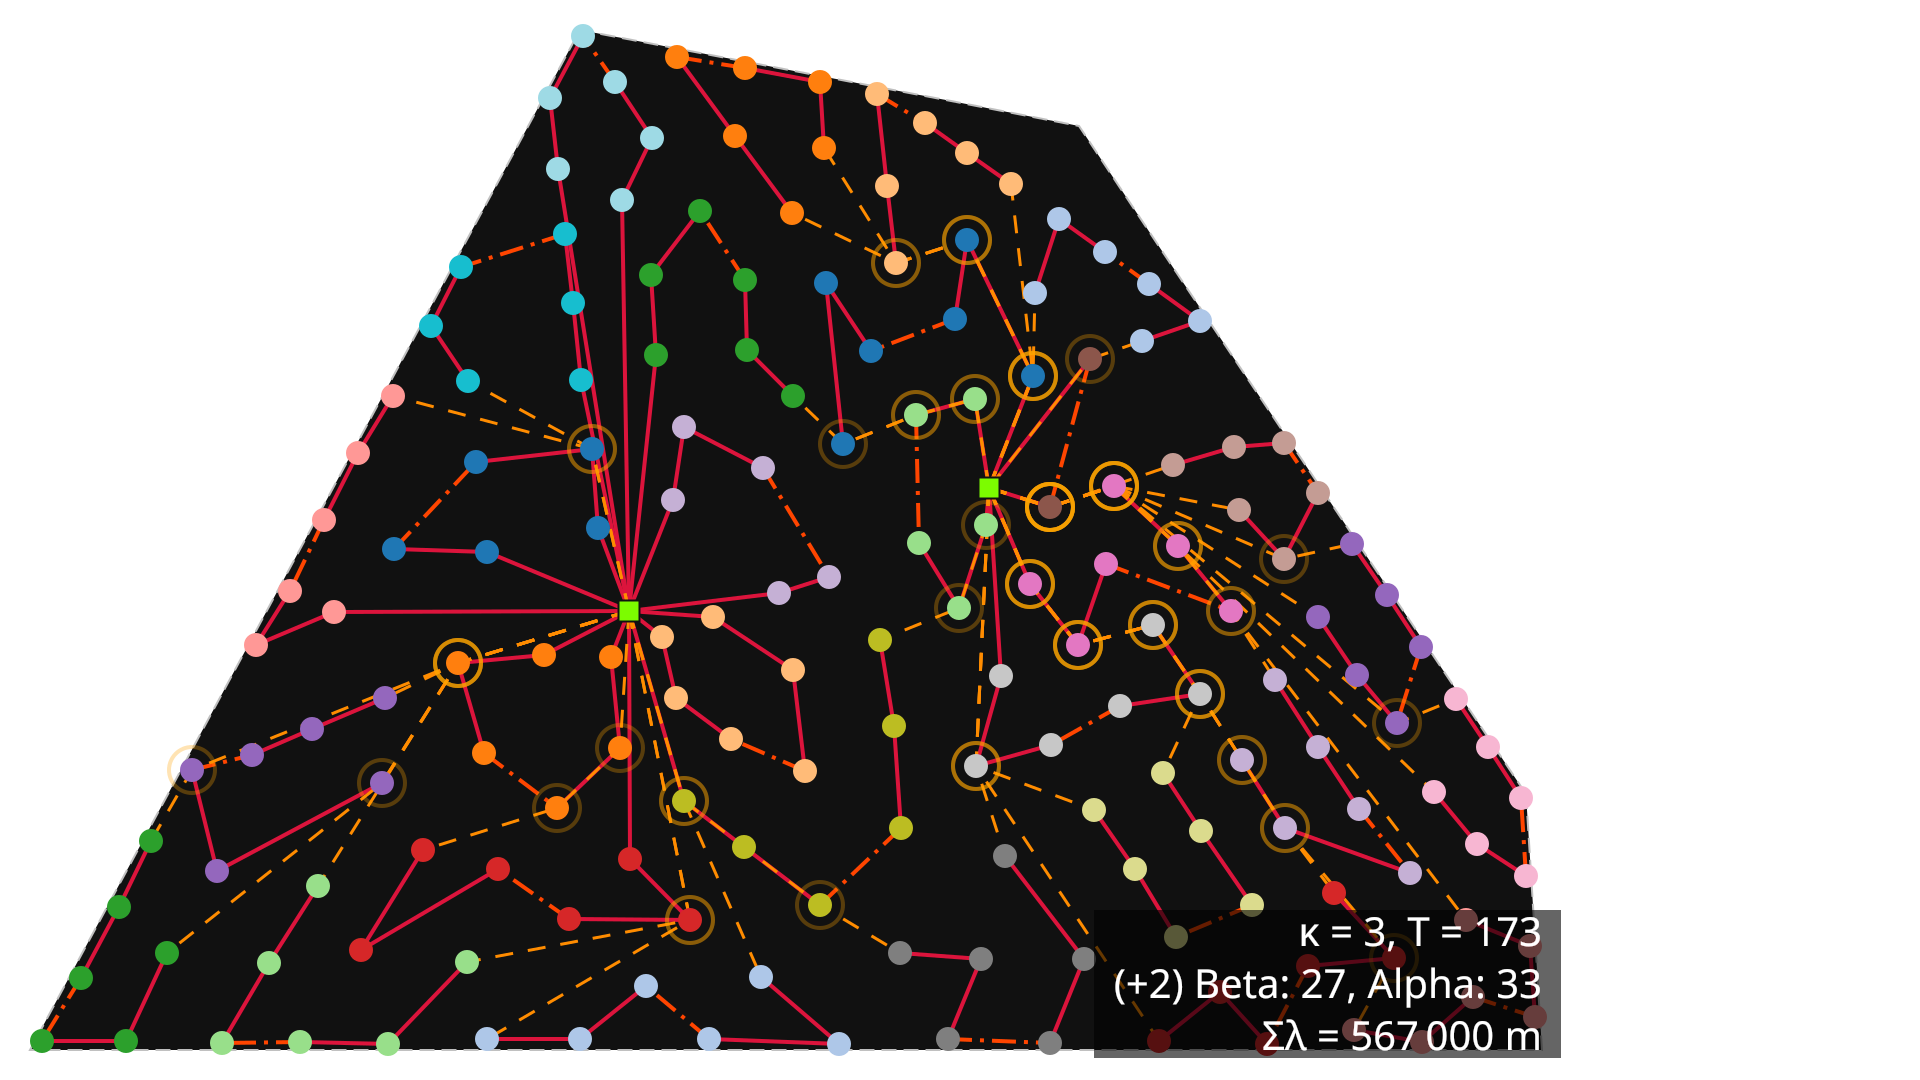

In [9]:
wfn.optimize(router=EWRouter(method='ringed'))
wfn

#### HGSRouter

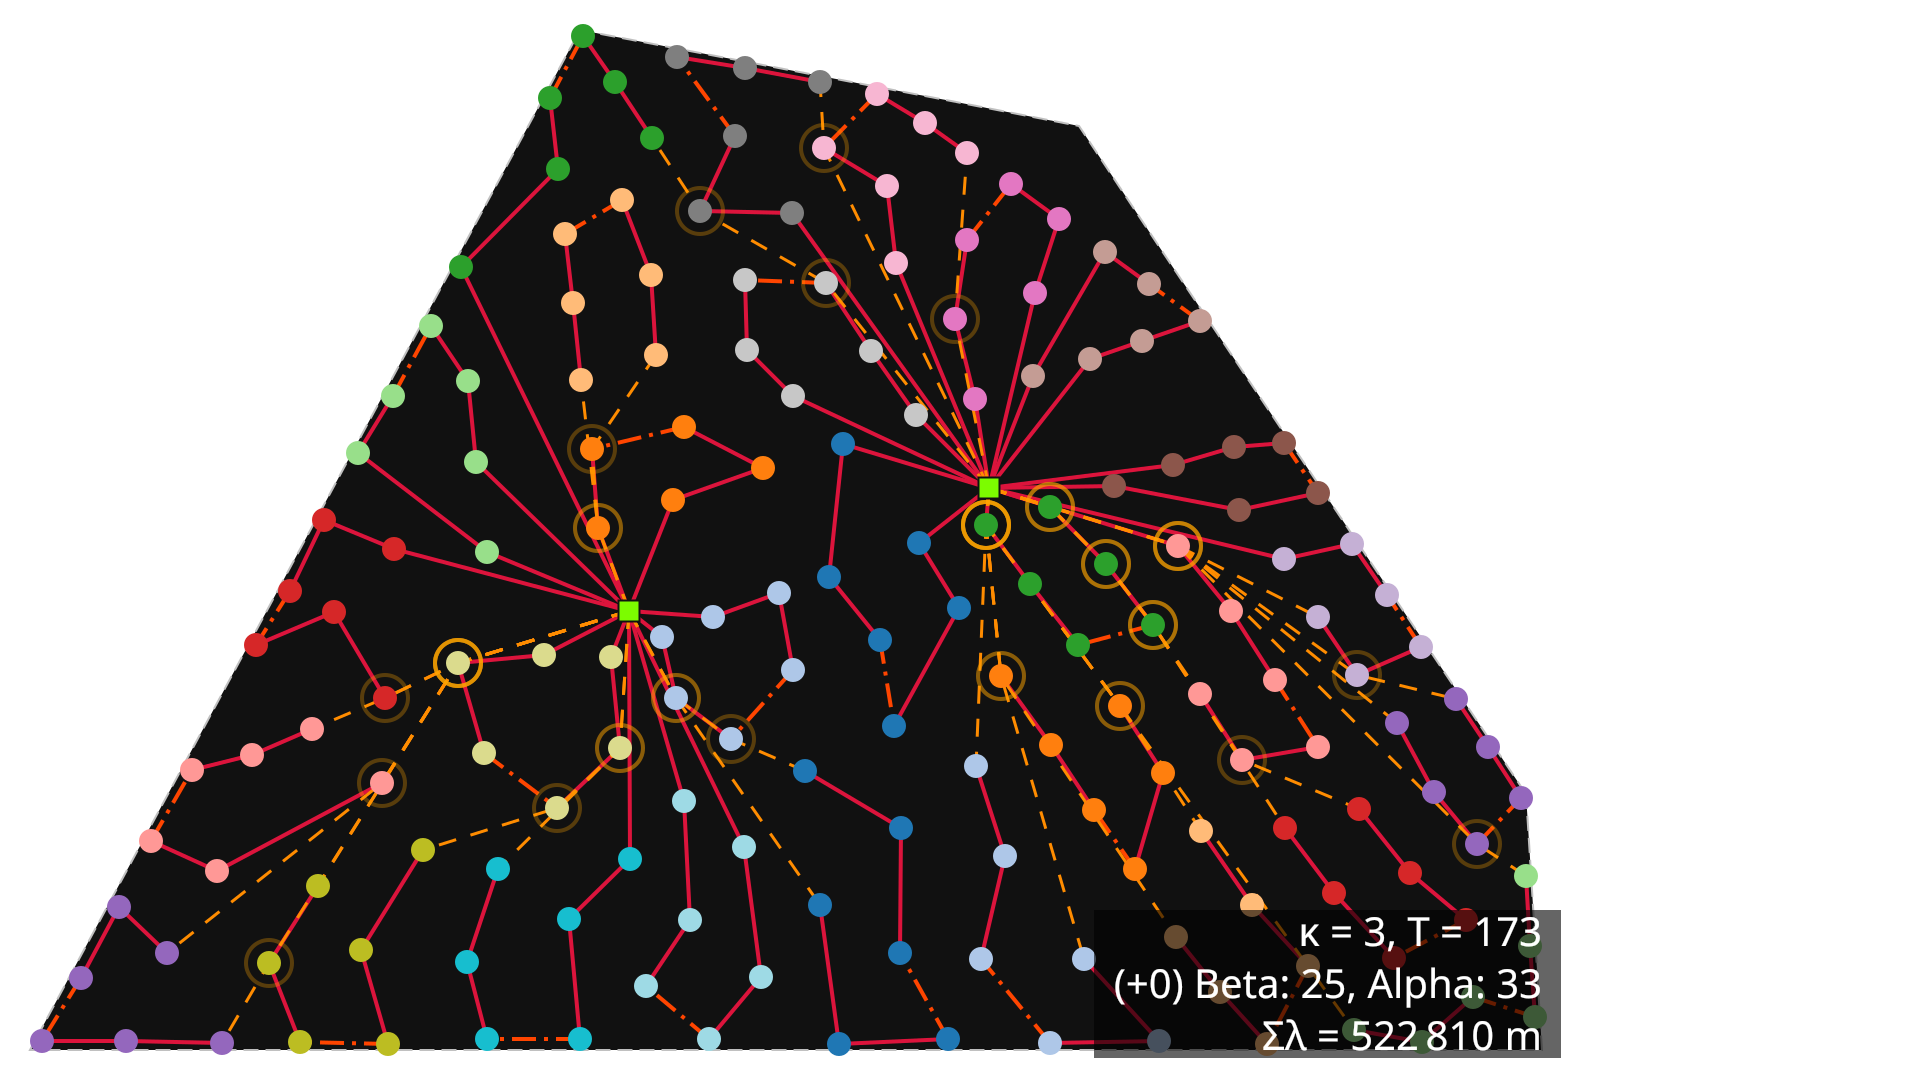

In [10]:
wfn.optimize(router=HGSRouter(ringed=True, time_limit=1.0))
wfn

#### MILPRouter

In [11]:
router_milp = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=90,
    mip_gap=0.005,
    model_options=ModelOptions(topology='ringed'),
    verbose=True,
)
wfn.optimize(router=router_milp)

IntegerBoundsPreprocessor                              6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]
BoundPropagationPreprocessor                           6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]
ImpliedIntegerPreprocessor                             6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]
IntegerBoundsPreprocessor                              6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]

Scaling to pure integer problem.
Num integers: 4438/4438 (implied: 0 in_inequalities: 0 max_scaling: 0) [IP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters: 

TerseLinks(scope='topology', topology='ringed', T=173, R=2, links=204)

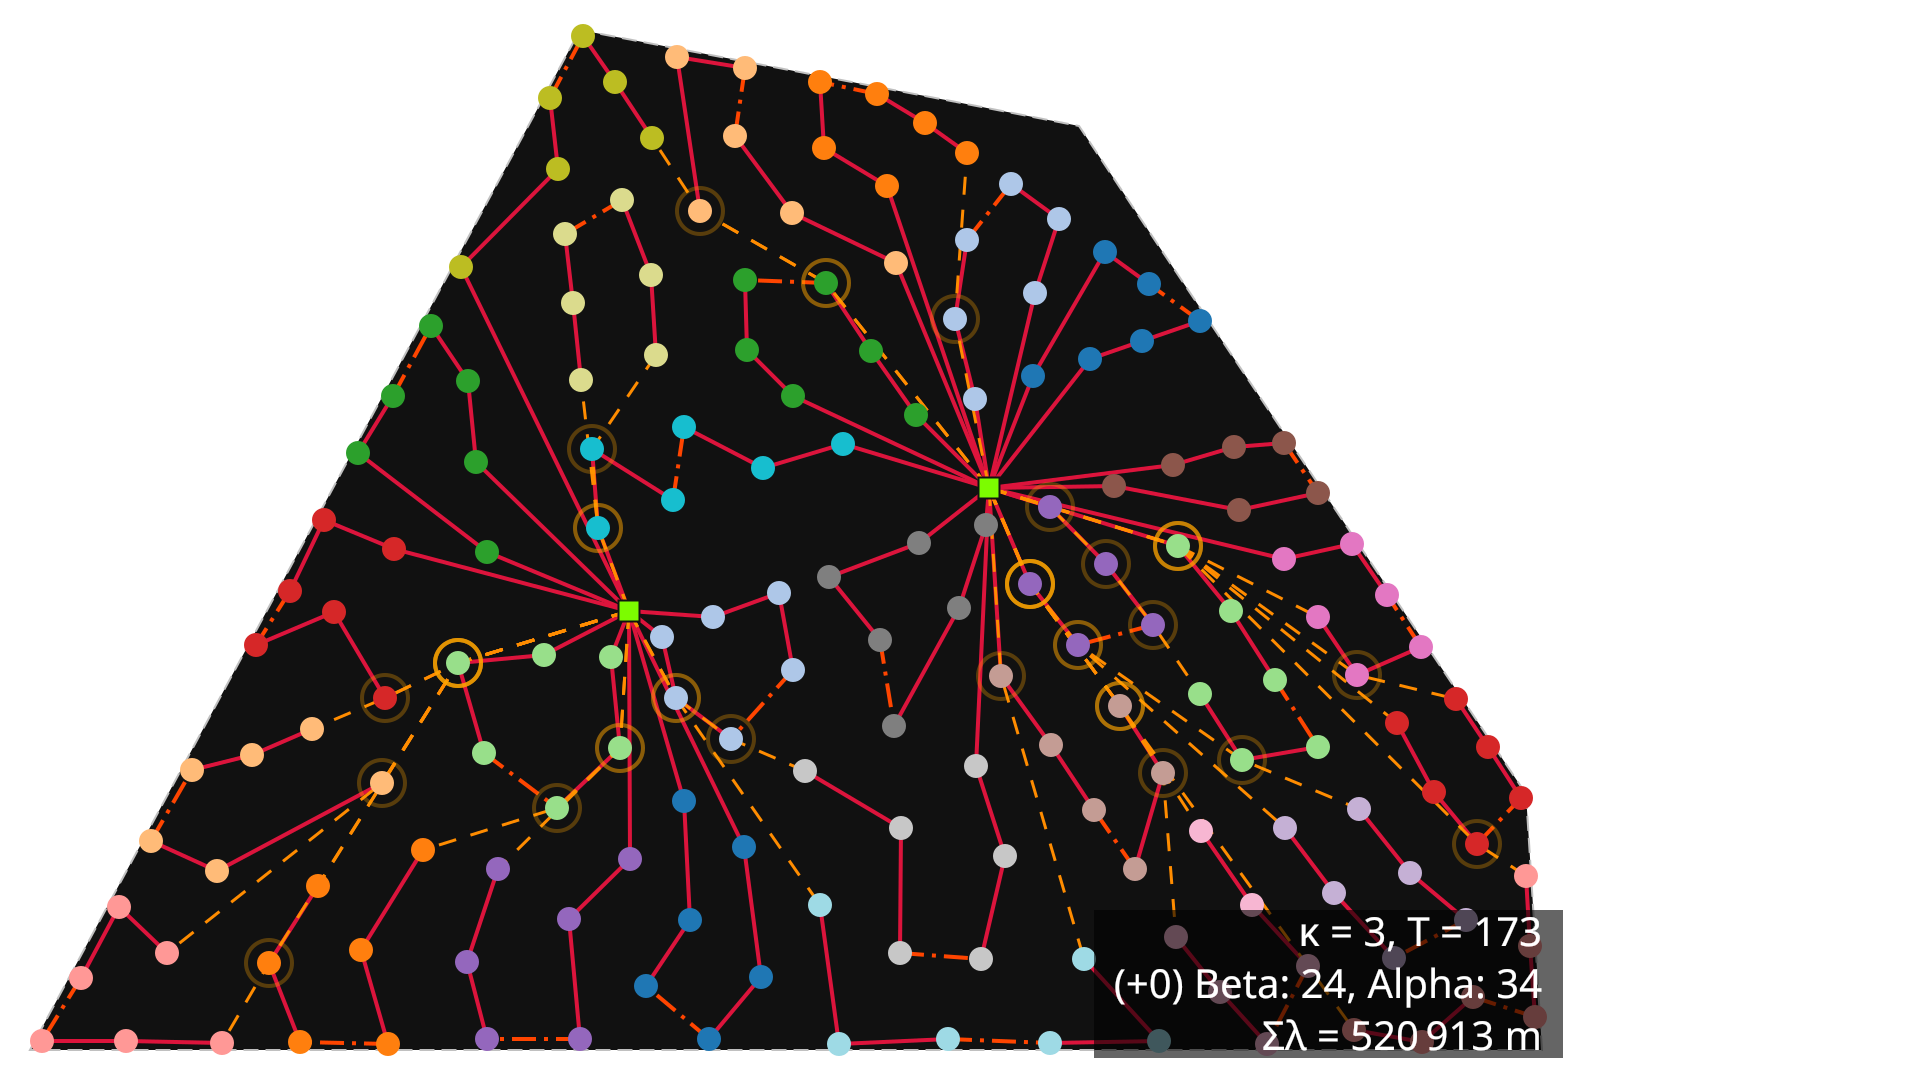

In [12]:
wfn